# Renewable Accessibility Index (RAI) Analysis

Computes a composite RAI score (0-1) for each of Texas's 254 counties, measuring
how well-positioned each county is to host large electricity loads powered by
renewable energy. The index is then overlaid with actual data-centre siting
to quantify the spatial mismatch.

In [56]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.geometry import Point
from pathlib import Path
from scipy import stats
import pickle, os

BASE = Path(r"C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub")
COUNTY_CACHE = BASE / "texas cleaned" / "texas_counties_cache.gpkg"
CAPACITY_PATH = BASE / "county_capacity_comparison - Copy.xlsx"
POP_PATH = BASE / "PopulationReport.xlsx"
GEOJSON_PATH = Path(r"C:\Users\pmeijer\Downloads\Electric_Power_Transmission_Lines_shp.geojson")
DC_PATH = BASE / "texas cleaned" / "data_centres_doe_texas_cleaned.xlsx"
CACHE_PATH = BASE / "rai_transmission_cache.pkl"

# --- 1. County boundaries ---
counties = gpd.read_file(COUNTY_CACHE)
counties["NAME_UPPER"] = counties["NAME"].astype(str).str.upper().str.strip()
counties_prj = counties.to_crs(epsg=3857)
counties_prj["area_sq_miles"] = counties_prj.geometry.area / 2.58999e6
counties["area_sq_miles"] = counties_prj["area_sq_miles"].values
print(f"Counties loaded: {len(counties)}")

# --- 2. Renewable / DC capacity by county ---
cap = pd.read_excel(CAPACITY_PATH)
cap["NAME_UPPER"] = cap["County"].astype(str).str.upper().str.strip()
counties = counties.merge(
    cap[["NAME_UPPER", "Wind Capacity (MW)", "Solar Capacity (MW)",
         "Total Renewable Capacity (MW)", "Data Center Demand (MW)"]],
    on="NAME_UPPER", how="left",
)
for col in ["Wind Capacity (MW)", "Solar Capacity (MW)",
            "Total Renewable Capacity (MW)", "Data Center Demand (MW)"]:
    counties[col] = counties[col].fillna(0)
print(f"Capacity data merged. Total renewable MW: {counties['Total Renewable Capacity (MW)'].sum():,.0f}")

# --- 3. Population by county ---
pop_df = pd.read_excel(POP_PATH, sheet_name="Population", header=1, usecols="C,H")
pop_df.columns = ["county_key", "population"]
pop_df["county_key"] = pop_df["county_key"].astype(str).str.strip().str.upper()
pop_df["population"] = pd.to_numeric(pop_df["population"], errors="coerce").fillna(0)
pop_df = pop_df[pop_df["county_key"] != "TEXAS"]
pop_df = pop_df.drop_duplicates("county_key")
counties = counties.merge(
    pop_df.rename(columns={"county_key": "NAME_UPPER"}),
    on="NAME_UPPER", how="left",
)
counties["population"] = counties["population"].fillna(0)
print(f"Population merged. Total pop: {counties['population'].sum():,.0f}")

# --- 4. Data centre locations ---
def parse_centroid(s):
    try:
        parts = str(s).replace("\xa0", " ").split(",")
        lon, lat = float(parts[0].strip()), float(parts[1].strip())
        if 25 <= lat <= 37 and -107 <= lon <= -93:
            return Point(lon, lat)
        if 25 <= lon <= 37 and -107 <= lat <= -93:
            return Point(lat, lon)
    except Exception:
        pass
    return None

dc_raw = pd.read_excel(DC_PATH, sheet_name="Data_Centres")
dc_raw = dc_raw[dc_raw["Name"].astype(str).str.contains(", TX", na=False)].copy()
for mw_col in ["Total MW", "Planned", "Operating", "In Construction",
                "Operating and In Construction "]:
    if mw_col in dc_raw.columns:
        dc_raw[mw_col] = pd.to_numeric(dc_raw[mw_col], errors="coerce").fillna(0)
dc_raw["committed_mw"] = dc_raw["Operating"] + dc_raw["In Construction"]
dc_raw["geometry"] = dc_raw["Centroid"].apply(parse_centroid)
dc_raw = dc_raw.dropna(subset=["geometry"])
gdf_dc = gpd.GeoDataFrame(dc_raw, geometry="geometry", crs="EPSG:4326")

total_mw = gdf_dc["Total MW"].sum()
committed = gdf_dc["committed_mw"].sum()
planned = gdf_dc["Planned"].sum()
operating = gdf_dc["Operating"].sum()
in_con = gdf_dc["In Construction"].sum()
print(f"Data centres loaded: {len(gdf_dc)} sites")
print(f"  Operating:        {operating:>10,.1f} MW  ({operating/total_mw*100:.0f}%)")
print(f"  In Construction:  {in_con:>10,.1f} MW  ({in_con/total_mw*100:.0f}%)")
print(f"  Committed (O+IC): {committed:>10,.1f} MW  ({committed/total_mw*100:.0f}%)")
print(f"  Planned:          {planned:>10,.1f} MW  ({planned/total_mw*100:.0f}%)")
print(f"  Total pipeline:   {total_mw:>10,.1f} MW")

Counties loaded: 254
Capacity data merged. Total renewable MW: 67,428
Population merged. Total pop: 29,145,459
Data centres loaded: 62 sites
  Operating:           9,044.2 MW  (22%)
  In Construction:     6,611.9 MW  (16%)
  Committed (O+IC):   15,656.1 MW  (38%)
  Planned:            25,785.3 MW  (62%)
  Total pipeline:     41,441.4 MW


In [57]:
# Cell 2: Transmission capacity density & HV line count per county
# Uses gpd.sjoin for speed; caches result to pickle.

if CACHE_PATH.exists():
    print("Loading transmission metrics from cache...")
    with open(CACHE_PATH, "rb") as f:
        tx_metrics = pickle.load(f)
    counties["capacity_density"] = counties["NAME_UPPER"].map(tx_metrics["capacity_density"]).fillna(0)
    counties["hv_line_count"] = counties["NAME_UPPER"].map(tx_metrics["hv_line_count"]).fillna(0)
    counties["total_gw_miles"] = counties["NAME_UPPER"].map(tx_metrics["total_gw_miles"]).fillna(0)
    print("  Loaded from cache.")
else:
    print("Loading HIFLD transmission lines (this may take 1-2 minutes)...")
    lines = gpd.read_file(GEOJSON_PATH)
    lines["VOLTAGE"] = pd.to_numeric(lines["VOLTAGE"], errors="coerce")

    texas_bounds = counties.total_bounds
    lines_tx = lines.cx[texas_bounds[0]:texas_bounds[2], texas_bounds[1]:texas_bounds[3]].copy()
    # HIFLD uses -999999 as sentinel for unknown voltage; drop non-positive
    lines_tx = lines_tx[lines_tx["VOLTAGE"] > 0].copy()
    print(f"  Texas lines (valid voltage): {len(lines_tx)}")

    # Project to metres for accurate length
    lines_prj = lines_tx.to_crs(epsg=3857)
    counties_prj2 = counties[["NAME_UPPER", "geometry"]].to_crs(epsg=3857)

    print("  Spatial join (lines -> counties)...")
    joined = gpd.sjoin(
        lines_prj[["VOLTAGE", "geometry"]],
        counties_prj2,
        predicate="intersects",
        how="inner",
    )
    joined["length_miles"] = joined.geometry.length / 1609.34
    joined["gw_miles"] = joined["VOLTAGE"].fillna(0) * joined["length_miles"] / 1000.0

    agg = joined.groupby("NAME_UPPER").agg(
        total_gw_miles=("gw_miles", "sum"),
        hv_line_count=("VOLTAGE", lambda x: int((x >= 345).sum())),
    ).reset_index()

    counties = counties.merge(agg, on="NAME_UPPER", how="left")
    counties["total_gw_miles"] = counties["total_gw_miles"].fillna(0)
    counties["hv_line_count"] = counties["hv_line_count"].fillna(0)
    counties["capacity_density"] = np.where(
        counties["area_sq_miles"] > 0,
        counties["total_gw_miles"] / counties["area_sq_miles"],
        0,
    )

    # Cache for next run
    tx_metrics = {
        "capacity_density": counties.set_index("NAME_UPPER")["capacity_density"].to_dict(),
        "hv_line_count": counties.set_index("NAME_UPPER")["hv_line_count"].to_dict(),
        "total_gw_miles": counties.set_index("NAME_UPPER")["total_gw_miles"].to_dict(),
    }
    with open(CACHE_PATH, "wb") as f:
        pickle.dump(tx_metrics, f)
    print("  Cached transmission metrics.")

print(f"\nTransmission summary:")
print(f"  Counties with lines: {(counties['total_gw_miles'] > 0).sum()}")
print(f"  Counties with HV (345+ kV): {(counties['hv_line_count'] > 0).sum()}")
print(f"  Max capacity density: {counties['capacity_density'].max():.4f} GW-mi/sq mi")
print(counties[["NAME_UPPER", "capacity_density", "hv_line_count", "total_gw_miles"]]
      .sort_values("capacity_density", ascending=False).head(10).to_string(index=False))

Loading transmission metrics from cache...
  Loaded from cache.

Transmission summary:
  Counties with lines: 253
  Counties with HV (345+ kV): 189
  Max capacity density: 0.7472 GW-mi/sq mi
NAME_UPPER  capacity_density  hv_line_count  total_gw_miles
  ROCKWALL          0.747195           10.0      158.284151
 SOMERVELL          0.384700            9.0      103.338461
 GUADALUPE          0.372460           21.0      353.246641
     TITUS          0.363981           12.0      221.949790
  FRANKLIN          0.343528            5.0      144.933755
    DALLAS          0.330774           35.0      426.254782
 WILBARGER          0.291485           10.0      416.596760
      HOOD          0.283691           13.0      174.460839
    COLLIN          0.280977           23.0      356.359485
      WISE          0.277184           13.0      366.341490


In [58]:
# Cell 3: Compute RAI components (v2 -- proper demand accounting)

# --- Assign DC MW by status to counties via spatial join ---
gdf_dc_prj = gdf_dc.to_crs(counties.crs)
dc_joined = gpd.sjoin(
    gdf_dc_prj[["Total MW", "committed_mw", "Planned", "Operating", "In Construction", "geometry"]],
    counties[["NAME_UPPER", "geometry"]],
    predicate="within", how="left",
)
dc_agg = dc_joined.groupby("NAME_UPPER").agg(
    dc_total=("Total MW", "sum"),
    dc_committed=("committed_mw", "sum"),
    dc_planned=("Planned", "sum"),
    dc_operating=("Operating", "sum"),
    dc_in_construction=("In Construction", "sum"),
).reset_index()
counties = counties.merge(dc_agg, on="NAME_UPPER", how="left")
for c in ["dc_total", "dc_committed", "dc_planned", "dc_operating", "dc_in_construction"]:
    counties[c] = counties[c].fillna(0)

# Also keep capacity-file DC demand as fallback
counties["dc_mw_total"] = counties[["dc_total", "Data Center Demand (MW)"]].max(axis=1)
counties["dc_mw_committed"] = counties["dc_committed"]

print(f"DC MW assigned to counties:")
print(f"  Total pipeline:   {counties['dc_mw_total'].sum():>10,.0f} MW across {(counties['dc_mw_total']>0).sum()} counties")
print(f"  Committed (O+IC): {counties['dc_mw_committed'].sum():>10,.0f} MW across {(counties['dc_mw_committed']>0).sum()} counties")

# --- Component 1: Renewable surplus ratio ---
MW_PER_CAPITA = 14000 / 8760 / 1000  # 14,000 kWh/capita/yr (EIA Texas avg)
counties["pop_demand_mw"] = counties["population"] * MW_PER_CAPITA

# Scenario A: committed DC only; Scenario B: full pipeline
counties["demand_A"] = (counties["pop_demand_mw"] + counties["dc_mw_committed"]).clip(lower=0.01)
counties["demand_B"] = (counties["pop_demand_mw"] + counties["dc_mw_total"]).clip(lower=0.01)

counties["surplus_A"] = (counties["Total Renewable Capacity (MW)"] / counties["demand_A"]).clip(upper=200)
counties["surplus_B"] = (counties["Total Renewable Capacity (MW)"] / counties["demand_B"]).clip(upper=200)

print(f"\nSurplus ratio (Scenario A -- committed DC):")
print(counties["surplus_A"].describe().round(2))
print(f"  Counties with surplus > 2.0: {(counties['surplus_A'] > 2.0).sum()}")
print(f"\nSurplus ratio (Scenario B -- full pipeline):")
print(counties["surplus_B"].describe().round(2))
print(f"  Counties with surplus > 2.0: {(counties['surplus_B'] > 2.0).sum()}")

# --- Component 3: Distance to nearest renewable-surplus county ---
# Use Scenario A surplus to define "surplus counties" (more conservative)
counties_prj3 = counties.to_crs(epsg=3857).copy()
counties_prj3["centroid"] = counties_prj3.geometry.centroid

surplus_mask = counties["surplus_A"] > 2.0
surplus_centroids = counties_prj3.loc[surplus_mask, "centroid"].values

dist_to_renewable = []
for idx, row in counties_prj3.iterrows():
    c = row["centroid"]
    if len(surplus_centroids) == 0:
        dist_to_renewable.append(500.0)
        continue
    dists = [c.distance(sc) for sc in surplus_centroids]
    d_miles = min(dists) / 1609.34
    dist_to_renewable.append(d_miles)
counties["dist_to_renewable_miles"] = dist_to_renewable
counties["prox_to_renewable"] = 1.0 / (counties["dist_to_renewable_miles"] + 1.0)

print(f"\nDistance to renewable surplus (miles):")
print(counties["dist_to_renewable_miles"].describe().round(1))

# --- Percentile ranks for both scenarios ---
counties["surplus_A_pct"] = counties["surplus_A"].rank(pct=True)
counties["surplus_B_pct"] = counties["surplus_B"].rank(pct=True)
counties["capacity_density_pct"] = counties["capacity_density"].rank(pct=True)
counties["prox_renewable_pct"] = counties["prox_to_renewable"].rank(pct=True)

print("\nPercentile rank distributions:")
for col in ["surplus_A_pct", "surplus_B_pct", "capacity_density_pct", "prox_renewable_pct"]:
    print(f"  {col}: mean={counties[col].mean():.3f}, std={counties[col].std():.3f}")

DC MW assigned to counties:
  Total pipeline:       41,441 MW across 62 counties
  Committed (O+IC):     15,656 MW across 57 counties

Surplus ratio (Scenario A -- committed DC):
count    254.00
mean      18.10
std       45.40
min        0.00
25%        0.00
50%        0.15
75%        9.22
max      200.00
Name: surplus_A, dtype: float64
  Counties with surplus > 2.0: 92

Surplus ratio (Scenario B -- full pipeline):
count    254.00
mean      17.56
std       45.25
min        0.00
25%        0.00
50%        0.09
75%        7.70
max      200.00
Name: surplus_B, dtype: float64
  Counties with surplus > 2.0: 89

Distance to renewable surplus (miles):
count    254.0
mean      37.3
std       40.5
min        0.0
25%        0.0
50%       35.6
75%       51.8
max      205.5
Name: dist_to_renewable_miles, dtype: float64

Percentile rank distributions:
  surplus_A_pct: mean=0.502, std=0.276
  surplus_B_pct: mean=0.502, std=0.276
  capacity_density_pct: mean=0.502, std=0.289
  prox_renewable_pct: mea

In [59]:
# Cell 4: Compute dual RAI (Scenario A = committed, Scenario B = full pipeline)

def compute_rai_and_classify(counties_df, surplus_pct_col, label):
    """Compute RAI from a given surplus percentile column and classify quartiles."""
    rai_col = f"RAI_{label}"
    q_col = f"RAI_quartile_{label}"
    counties_df[rai_col] = (
        0.5 * counties_df[surplus_pct_col]
        + 0.3 * counties_df["capacity_density_pct"]
        + 0.2 * counties_df["prox_renewable_pct"]
    )
    q25 = counties_df[rai_col].quantile(0.25)
    q50 = counties_df[rai_col].quantile(0.50)
    q75 = counties_df[rai_col].quantile(0.75)

    def classify(score):
        if score >= q75:   return "Q1 (Top 25%)"
        elif score >= q50: return "Q2 (50-75%)"
        elif score >= q25: return "Q3 (25-50%)"
        else:              return "Q4 (Bottom 25%)"

    counties_df[q_col] = counties_df[rai_col].apply(classify)
    return q25, q50, q75

# Scenario A: committed DC only (Operating + In Construction)
q25_A, q50_A, q75_A = compute_rai_and_classify(counties, "surplus_A_pct", "A")
# Scenario B: full pipeline (Total MW incl. Planned)
q25_B, q50_B, q75_B = compute_rai_and_classify(counties, "surplus_B_pct", "B")

# Primary RAI uses Scenario B (full pipeline -- the forward-looking view)
counties["RAI"] = counties["RAI_B"]
counties["RAI_quartile"] = counties["RAI_quartile_B"]
q25, q50, q75 = q25_B, q50_B, q75_B

for lbl, rai_col, qq in [("A (committed)", "RAI_A", (q25_A, q50_A, q75_A)),
                          ("B (full pipeline)", "RAI_B", (q25_B, q50_B, q75_B))]:
    print(f"\n{'='*60}")
    print(f"SCENARIO {lbl}")
    print(f"{'='*60}")
    print(counties[rai_col].describe().round(3))
    print(f"  Quartile thresholds: Q75={qq[2]:.3f}, Q50={qq[1]:.3f}, Q25={qq[0]:.3f}")

print(f"\nTop 15 DC counties (full pipeline RAI):")
dc_view = counties[counties["dc_mw_total"] > 0][
    ["NAME_UPPER", "RAI_A", "RAI_B", "dc_mw_committed", "dc_mw_total",
     "Total Renewable Capacity (MW)", "pop_demand_mw"]
].sort_values("dc_mw_total", ascending=False)
print(dc_view.head(15).to_string(index=False))


SCENARIO A (committed)
count    254.000
mean       0.502
std        0.207
min        0.118
25%        0.327
50%        0.504
75%        0.666
max        0.942
Name: RAI_A, dtype: float64
  Quartile thresholds: Q75=0.666, Q50=0.504, Q25=0.327

SCENARIO B (full pipeline)
count    254.000
mean       0.502
std        0.206
min        0.118
25%        0.328
50%        0.512
75%        0.667
max        0.942
Name: RAI_B, dtype: float64
  Quartile thresholds: Q75=0.667, Q50=0.512, Q25=0.328

Top 15 DC counties (full pipeline RAI):
NAME_UPPER    RAI_A    RAI_B  dc_mw_committed  dc_mw_total  Total Renewable Capacity (MW)  pop_demand_mw
      HOOD 0.523819 0.523819           300.00      5300.00                            0.0      98.444292
    DALLAS 0.552362 0.552362          1294.58      4205.80                            4.1    4173.599772
 CHILDRESS 0.592913 0.581102           800.00      2800.00                          240.0      10.656621
    TAYLOR 0.651181 0.649213          1412.00    

In [60]:
# Cell 5: Dual-scenario statistics + pipeline maturity

def quartile_table(counties_df, rai_col, q_col, dc_col, label):
    total = counties_df[dc_col].sum()
    qs = (
        counties_df.groupby(q_col)
        .agg(n=("NAME_UPPER","count"), dc=(dc_col,"sum"),
             ren=("Total Renewable Capacity (MW)","sum"), mean_rai=(rai_col,"mean"))
        .sort_index()
    )
    qs["dc_pct"] = (qs["dc"] / total * 100).round(1)
    qs["ren_pct"] = (qs["ren"] / qs["ren"].sum() * 100).round(1)
    qs["dc"] = qs["dc"].round(0)
    qs["ren"] = qs["ren"].round(0)
    qs["mean_rai"] = qs["mean_rai"].round(3)
    return qs, total

qs_A, total_A = quartile_table(counties, "RAI_A", "RAI_quartile_A", "dc_mw_committed", "A")
qs_B, total_B = quartile_table(counties, "RAI_B", "RAI_quartile_B", "dc_mw_total", "B")

# Store for use in chart cell
quartile_summary_A = qs_A
quartile_summary_B = qs_B
quartile_summary = qs_B  # primary scenario

for lbl, qs, tot in [("A: Committed (O+IC)", qs_A, total_A),
                      ("B: Full Pipeline", qs_B, total_B)]:
    print(f"\n{'='*70}")
    print(f"SCENARIO {lbl}  ({tot:,.0f} MW)")
    print(f"{'='*70}")
    display(qs)

# --- Headline comparison ---
q1_pct_A = qs_A.loc["Q1 (Top 25%)", "dc_pct"]
q1_pct_B = qs_B.loc["Q1 (Top 25%)", "dc_pct"]
below_A = counties.loc[counties["RAI_A"] < q50_A, "dc_mw_committed"].sum() / total_A * 100
below_B = counties.loc[counties["RAI_B"] < q50_B, "dc_mw_total"].sum() / total_B * 100

print(f"\n{'='*70}")
print("HEADLINE COMPARISON")
print(f"{'='*70}")
print(f"{'Metric':45s} {'Committed':>12s} {'Full Pipeline':>14s}")
print(f"{'-'*71}")
print(f"{'Total DC MW':45s} {total_A:>12,.0f} {total_B:>14,.0f}")
print(f"{'DC MW in top RAI quartile (%)':45s} {q1_pct_A:>11.1f}% {q1_pct_B:>13.1f}%")
print(f"{'DC MW below median RAI (%)':45s} {below_A:>11.1f}% {below_B:>13.1f}%")

dc_counties = counties[counties["dc_mw_total"] > 0]
non_dc = counties[counties["dc_mw_total"] == 0]
print(f"{'Mean RAI_B (DC counties)':45s} {dc_counties['RAI_B'].mean():>12.3f}")
print(f"{'Mean RAI_B (non-DC counties)':45s} {non_dc['RAI_B'].mean():>12.3f}")

# --- Pipeline maturity table ---
print(f"\n{'='*70}")
print("PIPELINE MATURITY BY TOP COUNTIES")
print(f"{'='*70}")
pipe = counties[counties["dc_mw_total"] > 0][
    ["NAME_UPPER", "dc_operating", "dc_in_construction", "dc_planned", "dc_mw_total",
     "RAI_B", "Total Renewable Capacity (MW)", "pop_demand_mw"]
].sort_values("dc_mw_total", ascending=False).head(15)
pipe.columns = ["County", "Operating", "In Constr.", "Planned", "Total", "RAI",
                "Renewable MW", "Pop Demand MW"]
for c in pipe.select_dtypes(include=[np.number]).columns:
    pipe[c] = pipe[c].round(1)
print(pipe.to_string(index=False))

# --- Top RAI counties ---
print(f"\n{'='*70}")
print("TOP 10 HIGHEST RAI (SCENARIO B) COUNTIES")
print(f"{'='*70}")
top = counties.nlargest(10, "RAI_B")[
    ["NAME_UPPER", "RAI_B", "dc_mw_total", "Total Renewable Capacity (MW)",
     "surplus_B", "pop_demand_mw", "capacity_density"]
].copy()
top.columns = ["County", "RAI", "DC MW", "Renewable MW", "Surplus", "Pop Demand MW", "Cap Density"]
print(top.to_string(index=False))


SCENARIO A: Committed (O+IC)  (15,656 MW)


,n,dc,ren,mean_rai,dc_pct,ren_pct
RAI_quartile_A,,,,,,
Q1 (Top 25%),64,765.0,41788.0,0.767,4.9,62.0
Q2 (50-75%),63,11780.0,23564.0,0.596,75.2,34.9
Q3 (25-50%),63,2548.0,2075.0,0.406,16.3,3.1
Q4 (Bottom 25%),64,564.0,0.0,0.239,3.6,0.0



SCENARIO B: Full Pipeline  (41,441 MW)


,n,dc,ren,mean_rai,dc_pct,ren_pct
RAI_quartile_B,,,,,,
Q1 (Top 25%),64,3745.0,42166.0,0.764,9.0,62.5
Q2 (50-75%),63,32413.0,23187.0,0.597,78.2,34.4
Q3 (25-50%),63,3655.0,2075.0,0.407,8.8,3.1
Q4 (Bottom 25%),64,1629.0,0.0,0.239,3.9,0.0



HEADLINE COMPARISON
Metric                                           Committed  Full Pipeline
-----------------------------------------------------------------------
Total DC MW                                         15,656         41,441
DC MW in top RAI quartile (%)                         4.9%           9.0%
DC MW below median RAI (%)                           19.9%          12.7%
Mean RAI_B (DC counties)                             0.528
Mean RAI_B (non-DC counties)                         0.493

PIPELINE MATURITY BY TOP COUNTIES
   County  Operating  In Constr.  Planned  Total  RAI  Renewable MW  Pop Demand MW
     HOOD      300.0         0.0   5000.0 5300.0  0.5           0.0           98.4
   DALLAS      688.8       605.8   2911.2 4205.8  0.6           4.1         4173.6
CHILDRESS      750.0        50.0   2000.0 2800.0  0.6         240.0           10.7
   TAYLOR        0.0      1412.0   1000.0 2412.0  0.6         970.1          228.9
   HARRIS      768.1       160.0   1262.6 2

Map saved: C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\rai_map.png


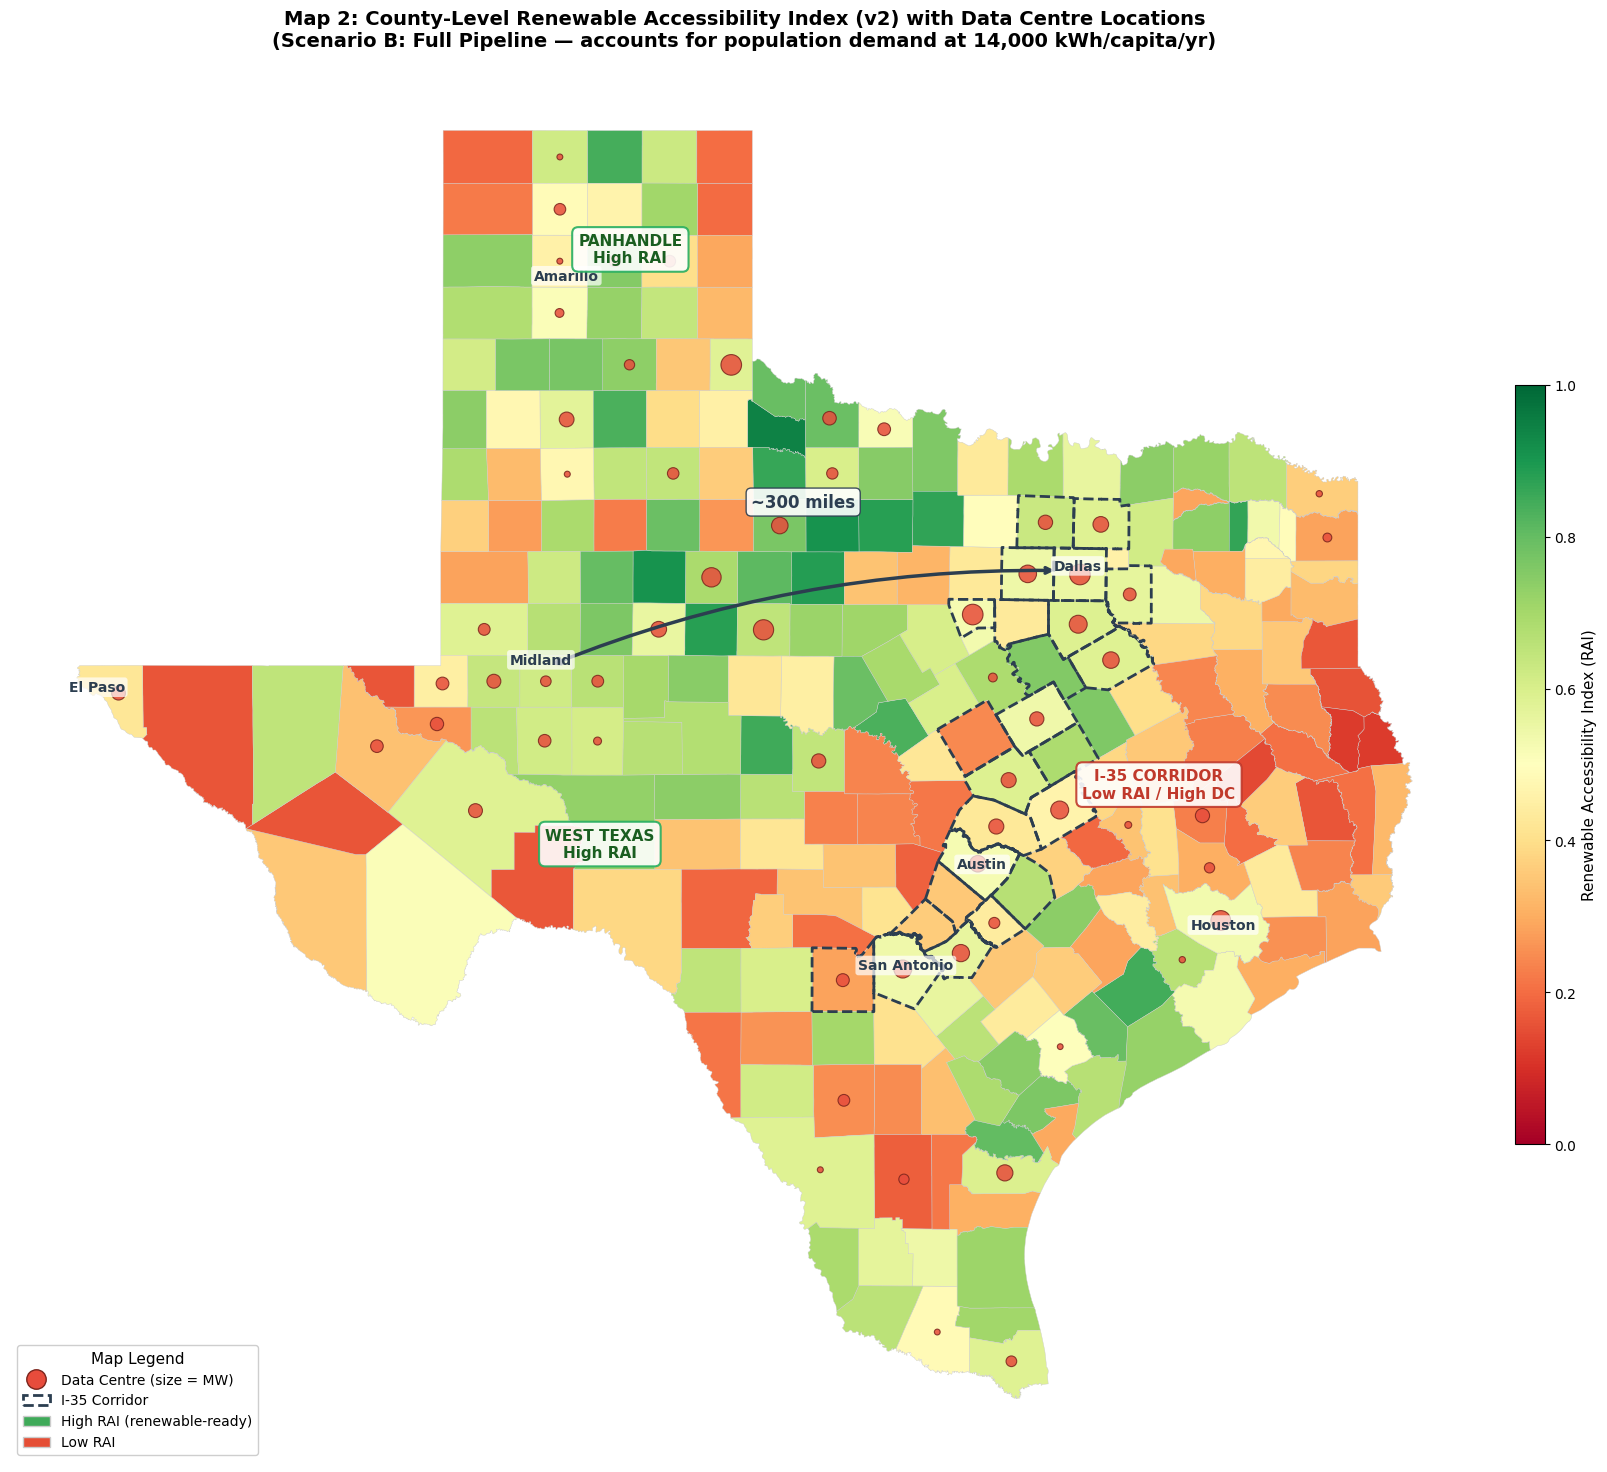

In [61]:
# Cell 6: Map 2 - County-Level Renewable Accessibility Index with DC Locations

I35_COUNTIES = [
    "DALLAS", "TARRANT", "COLLIN", "DENTON", "ELLIS",
    "HOOD", "JOHNSON", "KAUFMAN",
    "TRAVIS", "WILLIAMSON", "HAYS", "BASTROP",
    "BEXAR", "GUADALUPE", "COMAL", "MEDINA", "CALDWELL",
    "BELL", "MCLENNAN", "HILL", "CORYELL", "FALLS",
    "NAVARRO", "MILAM",
]
counties["is_i35"] = counties["NAME_UPPER"].isin(I35_COUNTIES)

fig, ax = plt.subplots(figsize=(18, 22))
ax.set_aspect("equal")

cmap_rai = plt.cm.RdYlGn
norm_rai = mcolors.Normalize(vmin=0, vmax=1)

counties.plot(
    ax=ax, column="RAI_B", cmap=cmap_rai, norm=norm_rai,
    edgecolor="#cccccc", linewidth=0.3,
)

# I-35 corridor highlight
i35_gdf = counties[counties["is_i35"]]
i35_gdf.plot(ax=ax, facecolor="none", edgecolor="#2c3e50", linewidth=2.0, linestyle="--", zorder=5)

# Data centre bubbles
dc_sizes = gdf_dc["Total MW"].apply(lambda mw: max(15, min(220, 15 + 4 * np.sqrt(max(0.1, mw)))))
ax.scatter(
    gdf_dc.geometry.x, gdf_dc.geometry.y,
    s=dc_sizes, c="#e74c3c", edgecolors="#7b241c", linewidths=0.8,
    zorder=10, alpha=0.85,
)

# City labels
CITIES = {
    "Dallas": (-96.80, 32.78), "Austin": (-97.74, 30.27),
    "San Antonio": (-98.49, 29.42), "Houston": (-95.37, 29.76),
    "Midland": (-102.08, 31.99), "Amarillo": (-101.83, 35.22),
    "El Paso": (-106.45, 31.76),
}
for city, (lon, lat) in CITIES.items():
    ax.annotate(
        city, (lon, lat), fontsize=10, fontweight="bold",
        color="#2c3e50", ha="center", va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.7),
        zorder=12,
    )

# Distance arrow
ax.annotate(
    "", xy=(-102.0, 32.0), xytext=(-97.0, 32.8),
    arrowprops=dict(arrowstyle="<->", color="#2c3e50", lw=2.5, connectionstyle="arc3,rad=0.1"),
    zorder=11,
)
ax.text(-99.5, 33.3, "~300 miles", fontsize=12, fontweight="bold", color="#2c3e50",
        ha="center", va="bottom",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#2c3e50", alpha=0.9),
        zorder=12)

# Region labels
ax.text(-101.5, 30.5, "WEST TEXAS\nHigh RAI", fontsize=11,
        fontweight="bold", color="#1a5e20", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#27ae60", alpha=0.9, linewidth=1.5),
        zorder=12)
ax.text(-101.2, 35.5, "PANHANDLE\nHigh RAI", fontsize=11,
        fontweight="bold", color="#1a5e20", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#27ae60", alpha=0.9, linewidth=1.5),
        zorder=12)
ax.text(-96.0, 31.0, "I-35 CORRIDOR\nLow RAI / High DC", fontsize=11,
        fontweight="bold", color="#c0392b", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#c0392b", alpha=0.9, linewidth=1.5),
        zorder=12)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap_rai, norm=norm_rai)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.35, pad=0.02, aspect=25)
cbar.set_label("Renewable Accessibility Index (RAI)", fontsize=11)

# Legend
legend_elements = [
    Line2D([0], [0], marker="o", markersize=14, color="w",
           markerfacecolor="#e74c3c", markeredgecolor="#7b241c",
           label="Data Centre (size = MW)", linestyle="None"),
    Patch(facecolor="none", edgecolor="#2c3e50", linewidth=2.0, linestyle="--",
          label="I-35 Corridor"),
    Patch(facecolor=cmap_rai(0.85), edgecolor="#cccccc", label="High RAI (renewable-ready)"),
    Patch(facecolor=cmap_rai(0.15), edgecolor="#cccccc", label="Low RAI"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=10,
          framealpha=0.95, title="Map Legend", title_fontsize=11)

ax.set_title(
    "Map 2: County-Level Renewable Accessibility Index (v2) with Data Centre Locations\n"
    "(Scenario B: Full Pipeline — accounts for population demand at 14,000 kWh/capita/yr)",
    fontsize=14, fontweight="bold", pad=15,
)
ax.set_axis_off()
plt.tight_layout()

map_path = str(BASE / "rai_map.png")
fig.savefig(map_path, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Map saved: {map_path}")
plt.show()

Combined chart saved: C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\rai_scatter.png


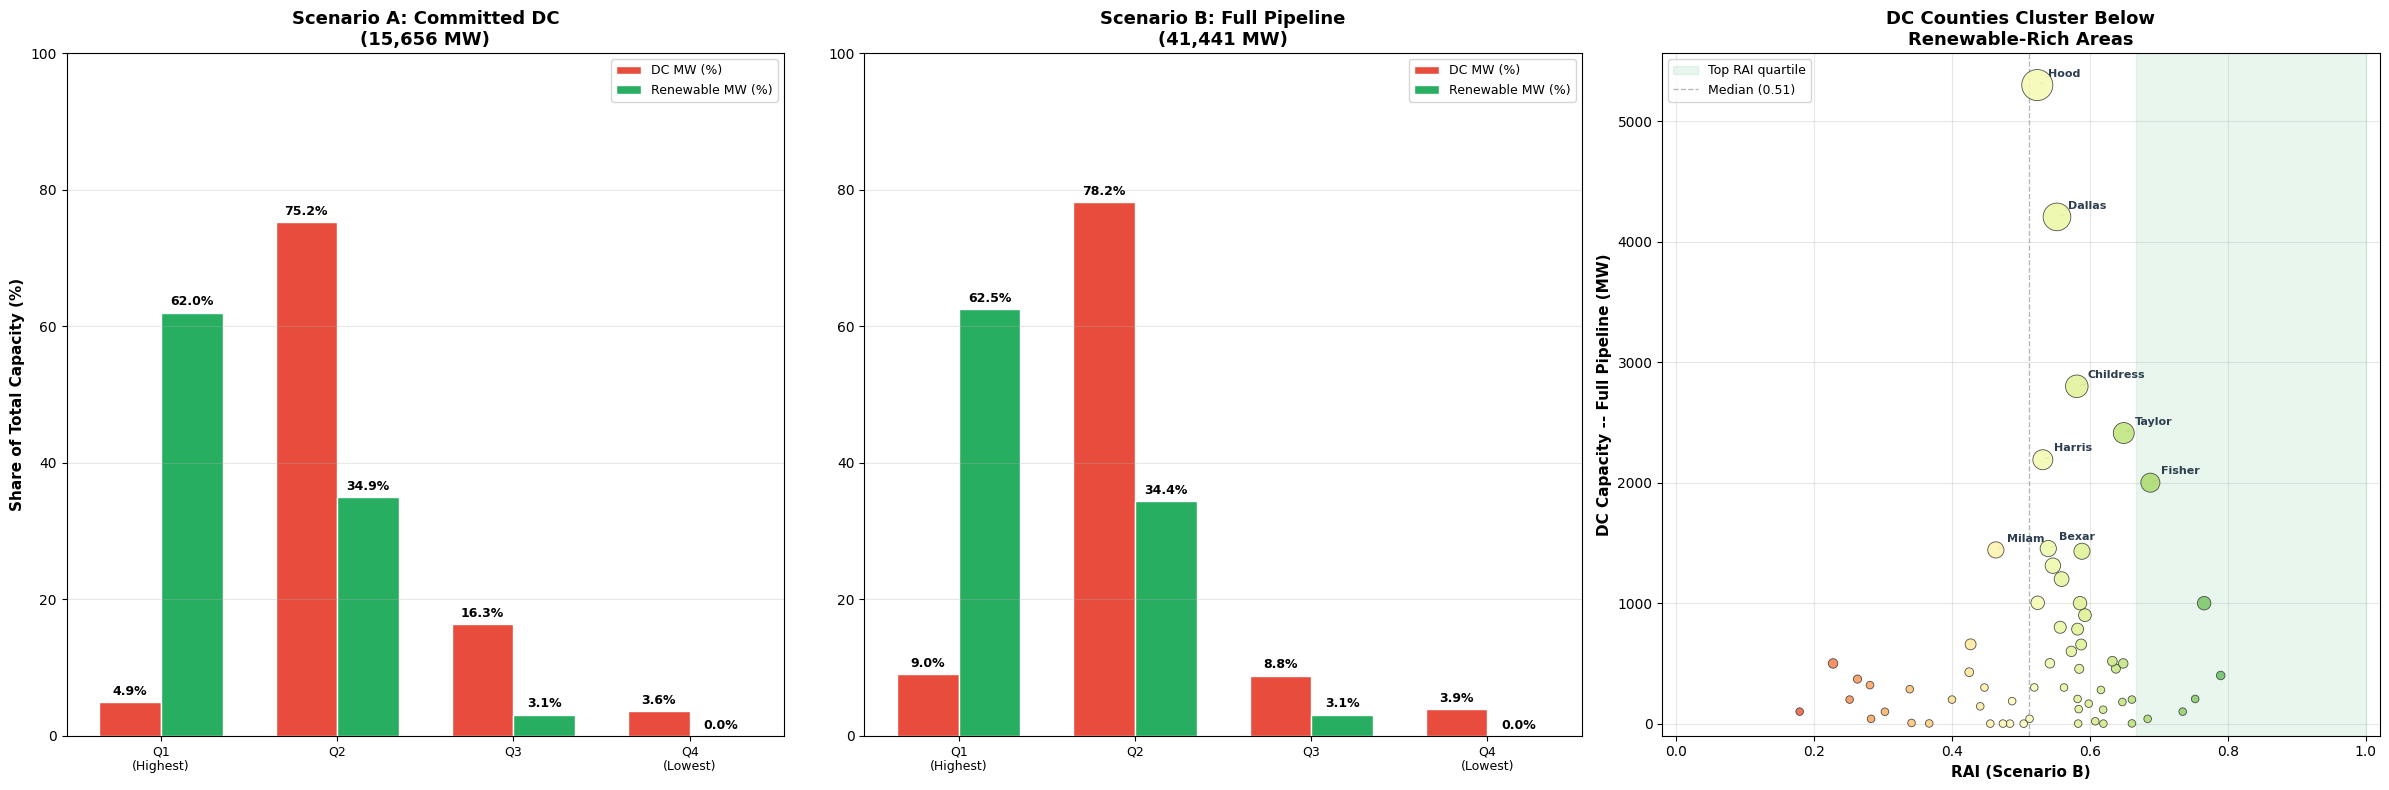

Scenario A saved: C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\rai_scenario_a_committed.png
Scenario B saved: C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\rai_scenario_b_full_pipeline.png
DC cluster scatter saved: C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\rai_dc_cluster_scatter.png


In [62]:
# Cell 7: Dual-scenario bar chart + scatter plot

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
quartiles = ["Q1 (Top 25%)", "Q2 (50-75%)", "Q3 (25-50%)", "Q4 (Bottom 25%)"]
x = np.arange(len(quartiles))
width = 0.35

# --- LEFT: Scenario A (Committed) ---
ax0 = axes[0]
dc_A = [quartile_summary_A.loc[q, "dc_pct"] for q in quartiles]
ren_A = [quartile_summary_A.loc[q, "ren_pct"] for q in quartiles]
b1 = ax0.bar(x - width/2, dc_A, width, label="DC MW (%)", color="#e74c3c", edgecolor="white")
b2 = ax0.bar(x + width/2, ren_A, width, label="Renewable MW (%)", color="#27ae60", edgecolor="white")
ax0.bar_label(b1, fmt="%.1f%%", padding=3, fontsize=9, fontweight="bold")
ax0.bar_label(b2, fmt="%.1f%%", padding=3, fontsize=9, fontweight="bold")
ax0.set_title(f"Scenario A: Committed DC\n({total_A:,.0f} MW)", fontsize=13, fontweight="bold")
ax0.set_xticks(x)
ax0.set_xticklabels(["Q1\n(Highest)", "Q2", "Q3", "Q4\n(Lowest)"], fontsize=9)
ax0.set_ylabel("Share of Total Capacity (%)", fontsize=11, fontweight="bold")
ax0.legend(fontsize=9, loc="upper right")
ax0.set_ylim(0, 100)
ax0.grid(axis="y", alpha=0.3)

# --- CENTRE: Scenario B (Full Pipeline) ---
ax1 = axes[1]
dc_B = [quartile_summary_B.loc[q, "dc_pct"] for q in quartiles]
ren_B = [quartile_summary_B.loc[q, "ren_pct"] for q in quartiles]
b3 = ax1.bar(x - width/2, dc_B, width, label="DC MW (%)", color="#e74c3c", edgecolor="white")
b4 = ax1.bar(x + width/2, ren_B, width, label="Renewable MW (%)", color="#27ae60", edgecolor="white")
ax1.bar_label(b3, fmt="%.1f%%", padding=3, fontsize=9, fontweight="bold")
ax1.bar_label(b4, fmt="%.1f%%", padding=3, fontsize=9, fontweight="bold")
ax1.set_title(f"Scenario B: Full Pipeline\n({total_B:,.0f} MW)", fontsize=13, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(["Q1\n(Highest)", "Q2", "Q3", "Q4\n(Lowest)"], fontsize=9)
ax1.legend(fontsize=9, loc="upper right")
ax1.set_ylim(0, 100)
ax1.grid(axis="y", alpha=0.3)

# --- RIGHT: Scatter (full pipeline, DC counties only) ---
ax2 = axes[2]
plot_df = counties[counties["dc_mw_total"] > 0].copy()
sizes = (plot_df["dc_mw_total"] / plot_df["dc_mw_total"].max() * 500).clip(lower=30)
sc = ax2.scatter(
    plot_df["RAI_B"], plot_df["dc_mw_total"],
    s=sizes, c=plot_df["RAI_B"], cmap="RdYlGn", norm=mcolors.Normalize(0, 1),
    edgecolors="#333333", linewidths=0.6, alpha=0.85, zorder=5,
)
ax2.axvspan(q75_B, 1.0, alpha=0.1, color="#27ae60", label="Top RAI quartile")
ax2.axvline(q50_B, color="#888888", linestyle="--", linewidth=1, alpha=0.6, label=f"Median ({q50_B:.2f})")

for _, row in plot_df.nlargest(8, "dc_mw_total").iterrows():
    ax2.annotate(row["NAME_UPPER"].title(), (row["RAI_B"], row["dc_mw_total"]),
                 textcoords="offset points", xytext=(8, 6), fontsize=8,
                 fontweight="bold", color="#2c3e50",
                 arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.8))
ax2.set_xlabel("RAI (Scenario B)", fontsize=11, fontweight="bold")
ax2.set_ylabel("DC Capacity -- Full Pipeline (MW)", fontsize=11, fontweight="bold")
ax2.set_title("DC Counties Cluster Below\nRenewable-Rich Areas", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9, loc="upper left")
ax2.set_xlim(-0.02, 1.02)
ax2.set_ylim(bottom=-100)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(str(BASE / "rai_scatter.png"), dpi=300, bbox_inches="tight", facecolor="white")
print(f"Combined chart saved: {BASE / 'rai_scatter.png'}")
plt.show()

# --- Export each panel independently ---
quartiles = ["Q1 (Top 25%)", "Q2 (50-75%)", "Q3 (25-50%)", "Q4 (Bottom 25%)"]
x = np.arange(len(quartiles))
width = 0.35

# 1. Scenario A (Committed) - standalone
fig_a, ax_a = plt.subplots(figsize=(8, 6))
dc_A = [quartile_summary_A.loc[q, "dc_pct"] for q in quartiles]
ren_A = [quartile_summary_A.loc[q, "ren_pct"] for q in quartiles]
ax_a.bar(x - width/2, dc_A, width, label="DC MW (%)", color="#e74c3c", edgecolor="white")
ax_a.bar(x + width/2, ren_A, width, label="Renewable MW (%)", color="#27ae60", edgecolor="white")
ax_a.bar_label(ax_a.containers[0], fmt="%.1f%%", padding=3, fontsize=10, fontweight="bold")
ax_a.bar_label(ax_a.containers[1], fmt="%.1f%%", padding=3, fontsize=10, fontweight="bold")
ax_a.set_title(f"Scenario A: Committed DC ({total_A:,.0f} MW)", fontsize=14, fontweight="bold")
ax_a.set_xticks(x)
ax_a.set_xticklabels(["Q1 (Highest RAI)", "Q2", "Q3", "Q4 (Lowest RAI)"], fontsize=10)
ax_a.set_ylabel("Share of Total Capacity (%)", fontsize=12, fontweight="bold")
ax_a.legend(fontsize=10, loc="upper right")
ax_a.set_ylim(0, 100)
ax_a.grid(axis="y", alpha=0.3)
plt.tight_layout()
path_a = str(BASE / "rai_scenario_a_committed.png")
fig_a.savefig(path_a, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig_a)
print(f"Scenario A saved: {path_a}")

# 2. Scenario B (Full Pipeline) - standalone
fig_b, ax_b = plt.subplots(figsize=(8, 6))
dc_B = [quartile_summary_B.loc[q, "dc_pct"] for q in quartiles]
ren_B = [quartile_summary_B.loc[q, "ren_pct"] for q in quartiles]
ax_b.bar(x - width/2, dc_B, width, label="DC MW (%)", color="#e74c3c", edgecolor="white")
ax_b.bar(x + width/2, ren_B, width, label="Renewable MW (%)", color="#27ae60", edgecolor="white")
ax_b.bar_label(ax_b.containers[0], fmt="%.1f%%", padding=3, fontsize=10, fontweight="bold")
ax_b.bar_label(ax_b.containers[1], fmt="%.1f%%", padding=3, fontsize=10, fontweight="bold")
ax_b.set_title(f"Scenario B: Full Pipeline ({total_B:,.0f} MW)", fontsize=14, fontweight="bold")
ax_b.set_xticks(x)
ax_b.set_xticklabels(["Q1 (Highest RAI)", "Q2", "Q3", "Q4 (Lowest RAI)"], fontsize=10)
ax_b.set_ylabel("Share of Total Capacity (%)", fontsize=12, fontweight="bold")
ax_b.legend(fontsize=10, loc="upper right")
ax_b.set_ylim(0, 100)
ax_b.grid(axis="y", alpha=0.3)
plt.tight_layout()
path_b = str(BASE / "rai_scenario_b_full_pipeline.png")
fig_b.savefig(path_b, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig_b)
print(f"Scenario B saved: {path_b}")

# 3. DC Counties Cluster Below Renewable-Rich Areas - standalone
fig_s, ax_s = plt.subplots(figsize=(10, 7))
plot_df = counties[counties["dc_mw_total"] > 0].copy()
sizes = (plot_df["dc_mw_total"] / plot_df["dc_mw_total"].max() * 500).clip(lower=30)
sc = ax_s.scatter(
    plot_df["RAI_B"], plot_df["dc_mw_total"],
    s=sizes, c=plot_df["RAI_B"], cmap="RdYlGn", norm=mcolors.Normalize(0, 1),
    edgecolors="#333333", linewidths=0.6, alpha=0.85, zorder=5,
)
ax_s.axvspan(q75_B, 1.0, alpha=0.1, color="#27ae60", label="Top RAI quartile")
ax_s.axvline(q50_B, color="#888888", linestyle="--", linewidth=1, alpha=0.6, label=f"Median ({q50_B:.2f})")
for _, row in plot_df.nlargest(8, "dc_mw_total").iterrows():
    ax_s.annotate(row["NAME_UPPER"].title(), (row["RAI_B"], row["dc_mw_total"]),
                  textcoords="offset points", xytext=(8, 6), fontsize=9,
                  fontweight="bold", color="#2c3e50",
                  arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.8))
ax_s.set_xlabel("Renewable Accessibility Index (RAI)", fontsize=12, fontweight="bold")
ax_s.set_ylabel("Data Centre Capacity (MW)", fontsize=12, fontweight="bold")
ax_s.set_title("DC Counties Cluster Below Renewable-Rich Areas", fontsize=14, fontweight="bold")
ax_s.legend(fontsize=10, loc="upper left")
ax_s.set_xlim(-0.02, 1.02)
ax_s.set_ylim(bottom=-100)
ax_s.grid(True, alpha=0.3)
plt.tight_layout()
path_s = str(BASE / "rai_dc_cluster_scatter.png")
fig_s.savefig(path_s, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig_s)
print(f"DC cluster scatter saved: {path_s}")

In [63]:
# Cell 8: Export county-level RAI v2 table to Excel (both scenarios)

export_cols = [
    "NAME_UPPER", "RAI_A", "RAI_quartile_A", "RAI_B", "RAI_quartile_B",
    "surplus_A", "surplus_B",
    "capacity_density", "capacity_density_pct",
    "dist_to_renewable_miles", "prox_renewable_pct",
    "dc_mw_total", "dc_mw_committed", "dc_operating", "dc_in_construction", "dc_planned",
    "Total Renewable Capacity (MW)", "Wind Capacity (MW)", "Solar Capacity (MW)",
    "population", "pop_demand_mw", "area_sq_miles",
    "hv_line_count", "total_gw_miles",
]
export_df = counties[export_cols].copy()
export_df = export_df.rename(columns={
    "NAME_UPPER": "County",
    "RAI_A": "RAI (Committed)", "RAI_quartile_A": "RAI Quartile (Committed)",
    "RAI_B": "RAI (Full Pipeline)", "RAI_quartile_B": "RAI Quartile (Full Pipeline)",
    "surplus_A": "Surplus Ratio (Committed)", "surplus_B": "Surplus Ratio (Full Pipeline)",
    "capacity_density": "Cap. Density (GW-mi/sq mi)",
    "capacity_density_pct": "Cap. Density (pct rank)",
    "dist_to_renewable_miles": "Dist. to Ren. Surplus (mi)",
    "prox_renewable_pct": "Proximity (pct rank)",
    "dc_mw_total": "DC Total MW", "dc_mw_committed": "DC Committed MW",
    "dc_operating": "DC Operating MW", "dc_in_construction": "DC In Construction MW",
    "dc_planned": "DC Planned MW",
    "Total Renewable Capacity (MW)": "Renewable MW",
    "population": "Population", "pop_demand_mw": "Pop. Demand (MW)",
    "area_sq_miles": "Area (sq mi)", "hv_line_count": "HV Lines (345+ kV)",
    "total_gw_miles": "Total GW-Miles",
})
export_df = export_df.sort_values("RAI (Full Pipeline)", ascending=False)

for c in export_df.select_dtypes(include=[np.number]).columns:
    export_df[c] = export_df[c].round(4)

# --- Data Centre MW by RAI Quartile (Appendix table) ---
quartile_order = ["Q1 (Top 25%)", "Q2 (50-75%)", "Q3 (25-50%)", "Q4 (Bottom 25%)"]
dc_quartile_table = pd.DataFrame({
    "RAI Quartile": quartile_order,
    "Committed MW": [quartile_summary_A.loc[q, "dc"] for q in quartile_order],
    "Committed (%)": [quartile_summary_A.loc[q, "dc_pct"] for q in quartile_order],
    "Full Pipeline MW": [quartile_summary_B.loc[q, "dc"] for q in quartile_order],
    "Full Pipeline (%)": [quartile_summary_B.loc[q, "dc_pct"] for q in quartile_order],
})
totals = pd.DataFrame({
    "RAI Quartile": ["Total"],
    "Committed MW": [total_A],
    "Committed (%)": [100.0],
    "Full Pipeline MW": [total_B],
    "Full Pipeline (%)": [100.0],
})
dc_quartile_table = pd.concat([dc_quartile_table, totals], ignore_index=True)
print("TABLE: Data Centre MW by RAI Quartile")
print("=" * 70)
print(dc_quartile_table.to_string(index=False))
print("=" * 70)
print(f"Pipeline maturity: Committed (O+IC) = {total_A:,.0f} MW ({100-62:.0f}%); Planned = {planned:,.0f} MW (62%)")

excel_path = str(BASE / "rai_county_analysis.xlsx")
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    export_df.to_excel(writer, sheet_name="County RAI v2", index=False)
    quartile_summary_A.to_excel(writer, sheet_name="Quartiles (Committed)")
    quartile_summary_B.to_excel(writer, sheet_name="Quartiles (Full Pipeline)")
    dc_quartile_table.to_excel(writer, sheet_name="Data Centre MW by RAI Quartile", index=False)

print(f"\nExcel exported: {excel_path}")
print(f"\nTop 5 counties by RAI (full pipeline):")
print(export_df.head(5)[["County", "RAI (Full Pipeline)", "DC Total MW", "Renewable MW"]].to_string(index=False))
print(f"\nBottom 5 counties by RAI (full pipeline):")
print(export_df.tail(5)[["County", "RAI (Full Pipeline)", "DC Total MW", "Renewable MW"]].to_string(index=False))

Excel exported: C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\rai_county_analysis.xlsx

Top 5 counties by RAI (full pipeline):
      County  RAI (Full Pipeline)  DC Total MW  Renewable MW
       FOARD               0.9421          0.0         555.3
THROCKMORTON               0.9091          0.0         559.2
      SCURRY               0.9079          0.0        2045.8
 SHACKELFORD               0.8866          0.0         565.6
       YOUNG               0.8795          0.0         698.0

Bottom 5 counties by RAI (full pipeline):
       County  RAI (Full Pipeline)  DC Total MW  Renewable MW
        TYLER               0.1620          0.0           0.0
       SHELBY               0.1565          0.0           0.0
      TRINITY               0.1419          0.0           0.0
SAN AUGUSTINE               0.1191          0.0           0.0
       SABINE               0.1179          0.0           0.0


## DAM Price Analysis: Temporal and Spatial Price Signals

In [64]:
# Cell 9: Load and aggregate ERCOT 2025 DAM prices across all months

DAM_PATH = BASE / "rpt.00013060.0000000000000000.DAMLZHBSPP_2025 (1).xlsx"
sheets = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

frames = []
for s in sheets:
    try:
        frames.append(pd.read_excel(DAM_PATH, sheet_name=s))
    except Exception:
        pass
dam = pd.concat(frames, ignore_index=True)
dam.columns = dam.columns.str.strip()
dam["Hour"] = dam["Hour Ending"].astype(str).str.extract(r"(\d+)").astype(int)
dam["Price"] = pd.to_numeric(dam["Settlement Point Price"], errors="coerce")
dam["SP"] = dam["Settlement Point"].str.strip()
print(f"DAM records loaded: {len(dam):,}  |  {dam['Delivery Date'].min()} to {dam['Delivery Date'].max()}")

# Average price by settlement point
avg_sp = dam.groupby("SP")["Price"].mean().sort_values()
print("\nAverage DAM price by zone ($/MWh):")
for sp in ["HB_PAN", "LZ_SOUTH", "LZ_NORTH", "LZ_HOUSTON", "LZ_WEST"]:
    print(f"  {sp:14s}: ${avg_sp[sp]:.2f}")

# Price by time window
print("\nPrice by time window ($/MWh):")
print(f"  {'Zone':14s}  {'Solar (10-15h)':>16s}  {'Evening (18-21h)':>16s}  {'Overnight (1-6h)':>16s}  {'Overall':>10s}")
for sp in ["LZ_WEST", "LZ_NORTH", "LZ_HOUSTON", "HB_PAN"]:
    sub = dam[dam["SP"] == sp]
    sol = sub[sub["Hour"].between(10, 15)]["Price"].mean()
    eve = sub[sub["Hour"].between(18, 21)]["Price"].mean()
    ngt = sub[sub["Hour"].between(1, 6)]["Price"].mean()
    ovr = sub["Price"].mean()
    print(f"  {sp:14s}  ${sol:>14.2f}  ${eve:>14.2f}  ${ngt:>14.2f}  ${ovr:>8.2f}")

DAM records loaded: 131,400  |  01/01/2025 to 12/31/2025

Average DAM price by zone ($/MWh):
  HB_PAN        : $25.44
  LZ_SOUTH      : $33.33
  LZ_NORTH      : $33.40
  LZ_HOUSTON    : $34.57
  LZ_WEST       : $42.72

Price by time window ($/MWh):
  Zone              Solar (10-15h)  Evening (18-21h)  Overnight (1-6h)     Overall
  LZ_WEST         $         20.43  $         65.63  $         47.04  $   42.72
  LZ_NORTH        $         22.18  $         57.44  $         27.07  $   33.40
  LZ_HOUSTON      $         25.72  $         57.02  $         27.08  $   34.57
  HB_PAN          $         15.82  $         46.87  $         20.08  $   25.44


Chart saved: C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\dam_hourly_prices.png


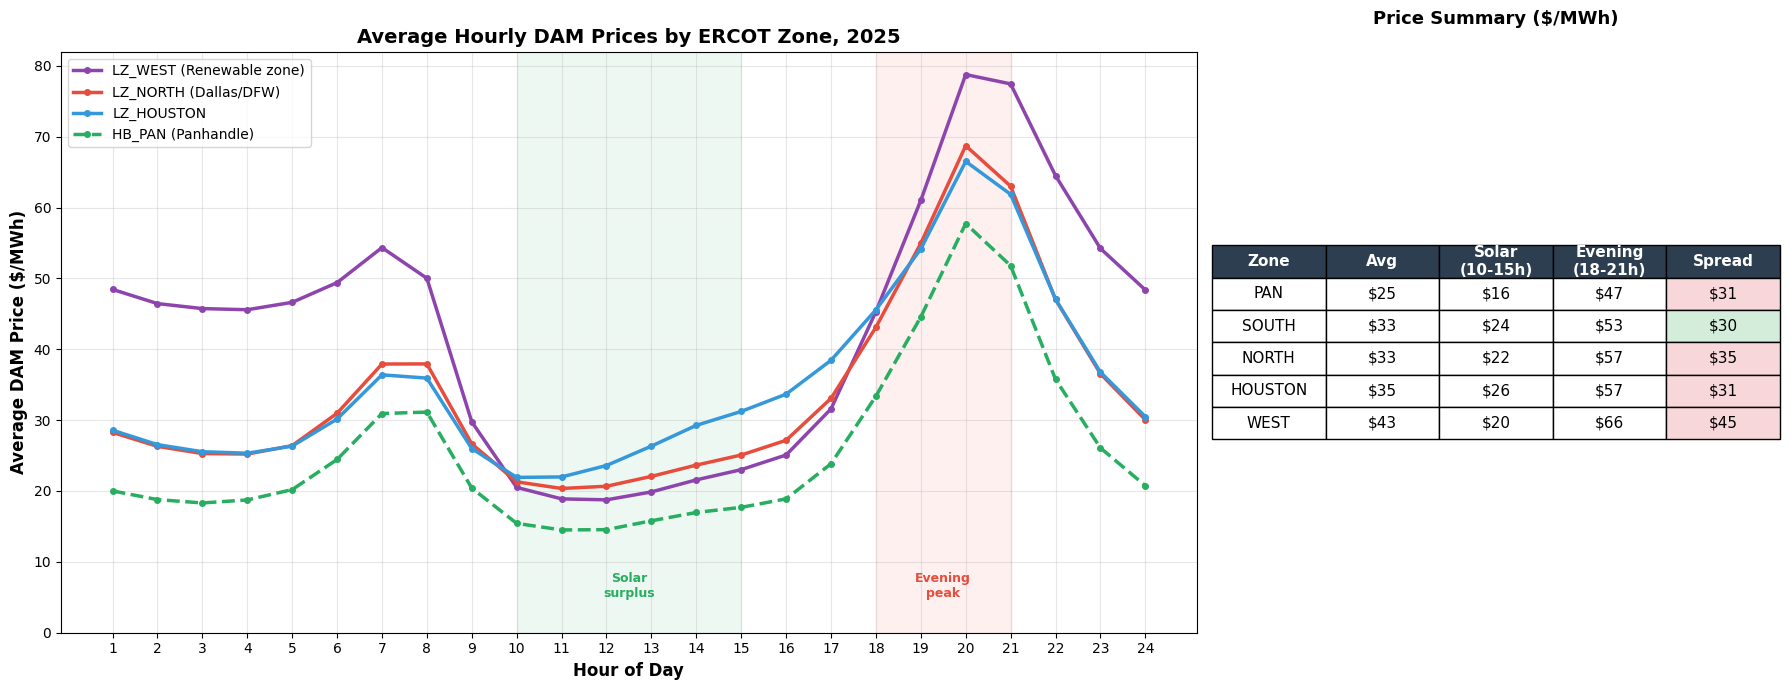

Chart only (no table) saved: C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\dam_hourly_prices_chart_only.png
Hourly averages + summary: C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\dam_hourly_averages.xlsx
DAM data exported: C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\dam_hourly_prices_data.xlsx


In [65]:
# Cell 10: Hourly DAM price chart + price summary table

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={"width_ratios": [2, 1]})

# LEFT: Hourly price curves
for sp, color, ls, lbl in [
    ("LZ_WEST", "#8e44ad", "-", "LZ_WEST (Renewable zone)"),
    ("LZ_NORTH", "#e74c3c", "-", "LZ_NORTH (Dallas/DFW)"),
    ("LZ_HOUSTON", "#3498db", "-", "LZ_HOUSTON"),
    ("HB_PAN", "#27ae60", "--", "HB_PAN (Panhandle)"),
]:
    sub = dam[dam["SP"] == sp]
    h = sub.groupby("Hour")["Price"].mean()
    ax1.plot(h.index, h.values, color=color, linewidth=2.5, linestyle=ls,
             label=lbl, marker="o", markersize=4)

ax1.axvspan(10, 15, alpha=0.08, color="#27ae60")
ax1.axvspan(18, 21, alpha=0.08, color="#e74c3c")
ax1.text(12.5, 5, "Solar\nsurplus", ha="center", fontsize=9, color="#27ae60", fontweight="bold")
ax1.text(19.5, 5, "Evening\npeak", ha="center", fontsize=9, color="#e74c3c", fontweight="bold")

ax1.set_xlabel("Hour of Day", fontsize=12, fontweight="bold")
ax1.set_ylabel("Average DAM Price ($/MWh)", fontsize=12, fontweight="bold")
ax1.set_title("Average Hourly DAM Prices by ERCOT Zone, 2025", fontsize=14, fontweight="bold")
ax1.legend(fontsize=10, loc="upper left")
ax1.set_xticks(range(1, 25))
ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.3)

# RIGHT: Summary table
zones = ["HB_PAN", "LZ_SOUTH", "LZ_NORTH", "LZ_HOUSTON", "LZ_WEST"]
rows = []
for sp in zones:
    sub = dam[dam["SP"] == sp]
    rows.append([
        sp.replace("LZ_", "").replace("HB_", ""),
        f"${sub['Price'].mean():.0f}",
        f"${sub[sub['Hour'].between(10,15)]['Price'].mean():.0f}",
        f"${sub[sub['Hour'].between(18,21)]['Price'].mean():.0f}",
        f"${sub[sub['Hour'].between(18,21)]['Price'].mean() - sub[sub['Hour'].between(10,15)]['Price'].mean():.0f}",
    ])

ax2.axis("off")
table = ax2.table(
    cellText=rows,
    colLabels=["Zone", "Avg", "Solar\n(10-15h)", "Evening\n(18-21h)", "Spread"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.0, 1.8)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif c == 4:
        val = int(rows[r-1][4].replace("$", ""))
        cell.set_facecolor("#f8d7da" if val > 30 else "#d4edda")
ax2.set_title("Price Summary ($/MWh)", fontsize=13, fontweight="bold", pad=20)

plt.tight_layout()
dam_path = str(BASE / "dam_hourly_prices.png")
fig.savefig(dam_path, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Chart saved: {dam_path}")
plt.show()

# --- Chart only (no table) ---
fig_chart, ax_chart = plt.subplots(figsize=(12, 6))
for sp, color, ls, lbl in [
    ("LZ_WEST", "#8e44ad", "-", "LZ_WEST (Renewable zone)"),
    ("LZ_NORTH", "#e74c3c", "-", "LZ_NORTH (Dallas/DFW)"),
    ("LZ_HOUSTON", "#3498db", "-", "LZ_HOUSTON"),
    ("HB_PAN", "#27ae60", "--", "HB_PAN (Panhandle)"),
]:
    sub = dam[dam["SP"] == sp]
    h = sub.groupby("Hour")["Price"].mean()
    ax_chart.plot(h.index, h.values, color=color, linewidth=2.5, linestyle=ls,
                  label=lbl, marker="o", markersize=4)
ax_chart.axvspan(10, 15, alpha=0.08, color="#27ae60")
ax_chart.axvspan(18, 21, alpha=0.08, color="#e74c3c")
ax_chart.text(12.5, 5, "Solar\nsurplus", ha="center", fontsize=9, color="#27ae60", fontweight="bold")
ax_chart.text(19.5, 5, "Evening\npeak", ha="center", fontsize=9, color="#e74c3c", fontweight="bold")
ax_chart.set_xlabel("Hour of Day", fontsize=12, fontweight="bold")
ax_chart.set_ylabel("Average DAM Price ($/MWh)", fontsize=12, fontweight="bold")
ax_chart.set_title("Average Hourly DAM Prices by ERCOT Zone, 2025", fontsize=14, fontweight="bold")
ax_chart.legend(fontsize=10, loc="upper left")
ax_chart.set_xticks(range(1, 25))
ax_chart.set_ylim(bottom=0)
ax_chart.grid(True, alpha=0.3)
plt.tight_layout()
chart_only_path = str(BASE / "dam_hourly_prices_chart_only.png")
fig_chart.savefig(chart_only_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig_chart)
print(f"Chart only (no table) saved: {chart_only_path}")

# --- Export DAM data to Excel ---
zones = ["HB_PAN", "LZ_SOUTH", "LZ_NORTH", "LZ_HOUSTON", "LZ_WEST"]
hourly_by_zone = dam[dam["SP"].isin(zones)].groupby(["SP", "Hour"])["Price"].mean().reset_index()
summary_rows = []
for sp in zones:
    sub = dam[dam["SP"] == sp]
    avg = sub["Price"].mean()
    solar = sub[sub["Hour"].between(10, 15)]["Price"].mean()
    evening = sub[sub["Hour"].between(18, 21)]["Price"].mean()
    overnight = sub[sub["Hour"].between(1, 6)]["Price"].mean()
    summary_rows.append({
        "Zone": sp,
        "Avg ($/MWh)": round(avg, 2),
        "Solar 10-15h ($/MWh)": round(solar, 2),
        "Evening 18-21h ($/MWh)": round(evening, 2),
        "Overnight 1-6h ($/MWh)": round(overnight, 2),
        "Spread Evening-Solar ($/MWh)": round(evening - solar, 2),
    })
summary_df = pd.DataFrame(summary_rows)

hourly_pivot = hourly_by_zone.pivot(index="Hour", columns="SP", values="Price").reset_index()
hourly_pivot = hourly_pivot[["Hour"] + zones]

hourly_only_path = str(BASE / "dam_hourly_averages.xlsx")
with pd.ExcelWriter(hourly_only_path, engine="openpyxl") as writer:
    hourly_pivot.to_excel(writer, sheet_name="Hourly Averages", index=False)
    summary_df.to_excel(writer, sheet_name="Price Summary", index=False)
print(f"Hourly averages + summary: {hourly_only_path}")

excel_path = str(BASE / "dam_hourly_prices_data.xlsx")
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    hourly_pivot.to_excel(writer, sheet_name="Hourly Chart Data", index=False)
    hourly_by_zone.to_excel(writer, sheet_name="Hourly Avg by Zone (long)", index=False)
    summary_df.to_excel(writer, sheet_name="Price Summary", index=False)
    dam[["Delivery Date", "Hour", "SP", "Price"]].to_excel(
        writer, sheet_name="Raw Data", index=False
    )
print(f"DAM data exported: {excel_path}")

In [66]:
# Cell 11: Cost-of-misalignment estimate (v2 — dual-scenario)

zone_prices = dam.groupby("SP")["Price"].mean()
other_price = (zone_prices["LZ_NORTH"] + zone_prices["LZ_SOUTH"]) / 2

CARBON_PRICE = 51   # EPA social cost of carbon $/tonne (2025)
CO2_FACTOR = 0.435  # tonnes CO2/MWh (EIA, gas-fired)
RENEWABLE_CF = 0.60 # share of shifted load served by local renewables

def cost_scenario(label, actual, rebalanced, total_mw):
    act_cost = sum(mw * (zone_prices.get(z, other_price) if z != "OTHER" else other_price) * 8760
                   for z, mw in actual.items()) / 1e9
    reb_cost = sum(mw * (zone_prices.get(z, other_price) if z != "OTHER" else other_price) * 8760
                   for z, mw in rebalanced.items()) / 1e9
    shifted = (rebalanced.get("LZ_WEST",0) - actual.get("LZ_WEST",0)) + \
              (rebalanced.get("HB_PAN",0) - actual.get("HB_PAN",0))
    avoided_mwh = shifted * 8760 * RENEWABLE_CF
    avoided_co2 = avoided_mwh * CO2_FACTOR / 1e6
    carbon_sav = avoided_co2 * CARBON_PRICE / 1e3
    print(f"\n  {label} ({total_mw:,.0f} MW)")
    print(f"    Actual elec. cost:     ${act_cost:.2f}B/yr")
    print(f"    Rebalanced elec. cost: ${reb_cost:.2f}B/yr")
    print(f"    MW shifted:            {shifted:,.0f}")
    print(f"    Avoided CO2:           {avoided_co2:.1f}M tonnes/yr")
    print(f"    Carbon savings:        ${carbon_sav:.2f}B/yr  (@${CARBON_PRICE}/t SCC)")
    print(f"    Net annual savings:    ${(act_cost - reb_cost + carbon_sav):.2f}B/yr")

# Scenario A: Committed only
ACTUAL_A = {"LZ_NORTH": 8500, "LZ_HOUSTON": 928, "LZ_SOUTH": 820,
            "LZ_WEST": 750, "HB_PAN": 1050, "OTHER": 3608}
REBAL_A = {"LZ_NORTH": 5100, "LZ_HOUSTON": 928, "LZ_SOUTH": 820,
           "LZ_WEST": 3000, "HB_PAN": 3200, "OTHER": 2608}

# Scenario B: Full pipeline
ACTUAL_B = {"LZ_NORTH": 22230, "LZ_HOUSTON": 2191, "LZ_SOUTH": 1454,
            "LZ_WEST": 2800, "HB_PAN": 2000, "OTHER": 10766}
REBAL_B = {"LZ_NORTH": 13338, "LZ_HOUSTON": 2191, "LZ_SOUTH": 1454,
           "LZ_WEST": 7692, "HB_PAN": 6000, "OTHER": 10766}

print("=" * 70)
print("COST OF MISALIGNMENT (DUAL SCENARIO)")
print("=" * 70)
cost_scenario("Scenario A: Committed (O+IC)", ACTUAL_A, REBAL_A, total_A)
cost_scenario("Scenario B: Full Pipeline", ACTUAL_B, REBAL_B, total_B)

print(f"\n{'='*70}")
print("KEY PRICE DIFFERENTIALS BY ZONE")
print(f"{'='*70}")
for z in ["HB_PAN", "LZ_WEST", "LZ_NORTH", "LZ_HOUSTON"]:
    p = zone_prices[z]
    sub = dam[dam["SP"] == z]
    sol = sub.loc[sub["Hour"].between(10,15), "Price"].mean()
    eve = sub.loc[sub["Hour"].between(18,21), "Price"].mean()
    print(f"  {z:14s}: avg ${p:.0f}  solar ${sol:.0f}  evening ${eve:.0f}  spread ${eve-sol:.0f} $/MWh")

COST OF MISALIGNMENT (DUAL SCENARIO)

  Scenario A: Committed (O+IC) (15,656 MW)
    Actual elec. cost:     $4.58B/yr
    Rebalanced elec. cost: $4.61B/yr
    MW shifted:            4,400
    Avoided CO2:           10.1M tonnes/yr
    Carbon savings:        $0.51B/yr  (@$51/t SCC)
    Net annual savings:    $0.48B/yr

  Scenario B: Full Pipeline (41,441 MW)
    Actual elec. cost:     $12.23B/yr
    Rebalanced elec. cost: $12.35B/yr
    MW shifted:            8,892
    Avoided CO2:           20.3M tonnes/yr
    Carbon savings:        $1.04B/yr  (@$51/t SCC)
    Net annual savings:    $0.92B/yr

KEY PRICE DIFFERENTIALS BY ZONE
  HB_PAN        : avg $25  solar $16  evening $47  spread $31 $/MWh
  LZ_WEST       : avg $43  solar $20  evening $66  spread $45 $/MWh
  LZ_NORTH      : avg $33  solar $22  evening $57  spread $35 $/MWh
  LZ_HOUSTON    : avg $35  solar $26  evening $57  spread $31 $/MWh
